In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi']        = 130
plt.rcParams['font.size']         = 11
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

df = pd.read_csv('data/processed/master_dataset.csv')
df['date'] = pd.to_datetime(df['date'])

TICKERS   = ['COST', 'WMT', 'TGT', 'LOW']
ALPHA     = 0.05   

print(f"Dataset loaded: {df.shape}")
print(f"Date range    : {df['date'].min().date()} → {df['date'].max().date()}")
print(f"Target balance: {df['target'].value_counts(normalize=True).round(3).to_dict()}")
print(f"\nSignificance level: α = {ALPHA}")
print("\nTests planned:")
print("  H1 — VIX level vs return direction (Mann-Whitney U)")
print("  H2 — 10Y rate vs return direction (Point-biserial + Mann-Whitney)")
print("  H3 — Op. margin change vs return direction (Point-biserial + Mann-Whitney)")
print("  H4 — Cross-stock return differences (Kruskal-Wallis + pairwise)")
print("  H5 — Net margin vs monthly return (Spearman)")

Dataset loaded: (284, 13)
Date range    : 2020-02-29 → 2025-12-31
Target balance: {1: 0.57, 0: 0.43}

Significance level: α = 0.05

Tests planned:
  H1 — VIX level vs return direction (Mann-Whitney U)
  H2 — 10Y rate vs return direction (Point-biserial + Mann-Whitney)
  H3 — Op. margin change vs return direction (Point-biserial + Mann-Whitney)
  H4 — Cross-stock return differences (Kruskal-Wallis + pairwise)
  H5 — Net margin vs monthly return (Spearman)


H1 — Does VIX level predict monthly return direction?

Null hypothesis (H₀): The return distribution is identical
  regardless of whether VIX is above or below its median.
Alternative  (H₁): Low-VIX months have significantly higher
  returns than high-VIX months.

VIX median split point : 19.76
Low-VIX group  (n=144)  — median return: 0.0115
High-VIX group (n=140) — median return: 0.0196

Mann-Whitney U statistic : 9258.0
p-value                  : 0.882714
Significant at α=0.05  : NO ✗
Effect size (rank-biserial r): 0.0815
  (0.1 = small, 0.3 = medium, 0.5 = large)

Per-stock: up-month rate in low vs high VIX months:
  COST: low VIX 61% vs high VIX 63%
  WMT: low VIX 67% vs high VIX 63%
  TGT: low VIX 47% vs high VIX 54%
  LOW: low VIX 44% vs high VIX 57%


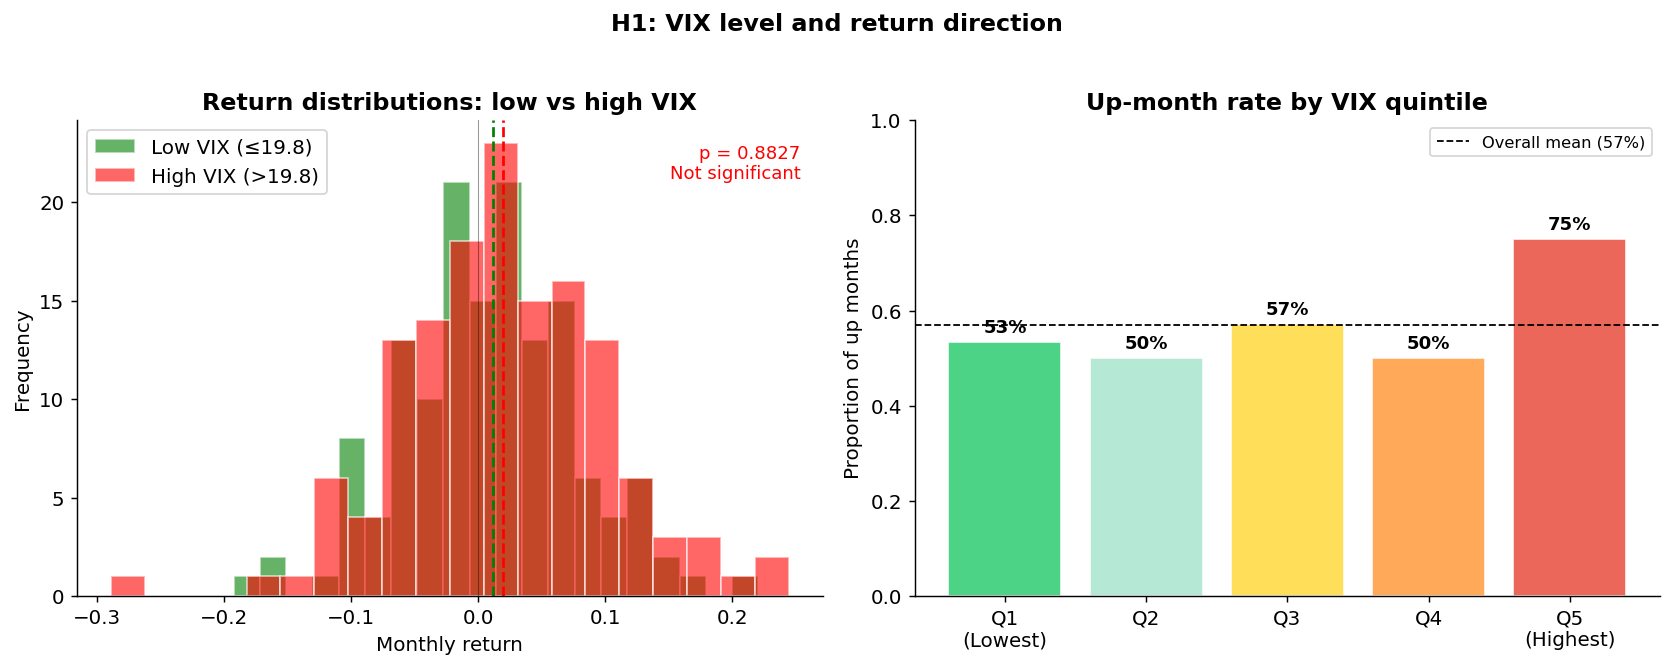


INTERPRETATION:
  Fail to reject H₀ (p=0.8827). No significant difference detected.


In [2]:
print("=" * 60)
print("H1 — Does VIX level predict monthly return direction?")
print("=" * 60)
print("\nNull hypothesis (H₀): The return distribution is identical")
print("  regardless of whether VIX is above or below its median.")
print("Alternative  (H₁): Low-VIX months have significantly higher")
print("  returns than high-VIX months.\n")

vix_median = df['vix_avg'].median()
low_vix    = df[df['vix_avg'] <= vix_median]['monthly_return']
high_vix   = df[df['vix_avg'] >  vix_median]['monthly_return']

print(f"VIX median split point : {vix_median:.2f}")
print(f"Low-VIX group  (n={len(low_vix)})  — median return: {low_vix.median():.4f}")
print(f"High-VIX group (n={len(high_vix)}) — median return: {high_vix.median():.4f}")

# Mann-Whitney U 
stat, p = stats.mannwhitneyu(low_vix, high_vix, alternative='greater')

print(f"\nMann-Whitney U statistic : {stat:.1f}")
print(f"p-value                  : {p:.6f}")
print(f"Significant at α={ALPHA}  : {'YES ✓' if p < ALPHA else 'NO ✗'}")

# also compute effect size (rank-biserial correlation)
n1, n2  = len(low_vix), len(high_vix)
rbc     = 1 - (2 * stat) / (n1 * n2)
print(f"Effect size (rank-biserial r): {rbc:.4f}")
print("  (0.1 = small, 0.3 = medium, 0.5 = large)")

# per-stock breakdown
print("\nPer-stock: up-month rate in low vs high VIX months:")
for ticker in TICKERS:
    sub = df[df['ticker'] == ticker]
    lo  = sub[sub['vix_avg'] <= vix_median]['target'].mean()
    hi  = sub[sub['vix_avg'] >  vix_median]['target'].mean()
    print(f"  {ticker}: low VIX {lo:.0%} vs high VIX {hi:.0%}")

# visualisation
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.hist(low_vix,  bins=20, alpha=0.6, color='green',
         label=f'Low VIX (≤{vix_median:.1f})', edgecolor='white')
ax1.hist(high_vix, bins=20, alpha=0.6, color='red',
         label=f'High VIX (>{vix_median:.1f})', edgecolor='white')
ax1.axvline(low_vix.median(),  color='green', linestyle='--', linewidth=1.5)
ax1.axvline(high_vix.median(), color='red',   linestyle='--', linewidth=1.5)
ax1.axvline(0, color='black', linewidth=0.6, alpha=0.4)
ax1.set_xlabel('Monthly return')
ax1.set_ylabel('Frequency')
ax1.set_title('Return distributions: low vs high VIX', fontweight='bold')
ax1.legend()
ax1.text(0.97, 0.95, f'p = {p:.4f}\n{"Significant" if p < ALPHA else "Not significant"}',
         transform=ax1.transAxes, ha='right', va='top',
         fontsize=10, color='darkgreen' if p < ALPHA else 'red')

vix_q    = pd.qcut(df['vix_avg'], q=5,
                   labels=['Q1\n(Lowest)', 'Q2', 'Q3', 'Q4', 'Q5\n(Highest)'])
up_rates = df.groupby(vix_q, observed=True)['target'].mean()
colors_q = ['#2ecc71','#a8e6cf','#ffd93d','#ff9a3c','#e74c3c']
bars = ax2.bar(up_rates.index, up_rates.values, color=colors_q, alpha=0.85, edgecolor='white')
ax2.axhline(df['target'].mean(), color='black', linestyle='--',
            linewidth=1, label=f'Overall mean ({df["target"].mean():.0%})')
ax2.set_ylim(0, 1)
ax2.set_title('Up-month rate by VIX quintile', fontweight='bold')
ax2.set_ylabel('Proportion of up months')
ax2.legend(fontsize=9)
for bar, val in zip(bars, up_rates.values):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 0.02,
             f'{val:.0%}', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('H1: VIX level and return direction', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plots/h1_vix_test.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nINTERPRETATION:")
if p < ALPHA:
    print(f"  Reject H₀. Low-VIX months have significantly higher returns")
    print(f"  than high-VIX months (p={p:.4f}). Market fear, as measured by")
    print(f"  VIX, is negatively associated with retail stock return direction.")
else:
    print(f"  Fail to reject H₀ (p={p:.4f}). No significant difference detected.")

H2 — Does the 10Y rate predict monthly return direction?

Null hypothesis (H₀): No correlation between rate_10y and target.
Alternative  (H₁): Rate level is associated with return direction.

Rate median split point : 3.57%

Point-biserial correlation:
  r = -0.0408,  p = 0.493737
  Significant: NO ✗

Mann-Whitney U (two-sided):
  statistic = 10390.0,  p = 0.654670
  Significant: NO ✗

Per-stock point-biserial correlation (rate vs target):
  COST: r=-0.1123, p=0.3513 
  WMT: r=+0.1150, p=0.3398 
  TGT: r=-0.0952, p=0.4297 
  LOW: r=-0.0671, p=0.5781 


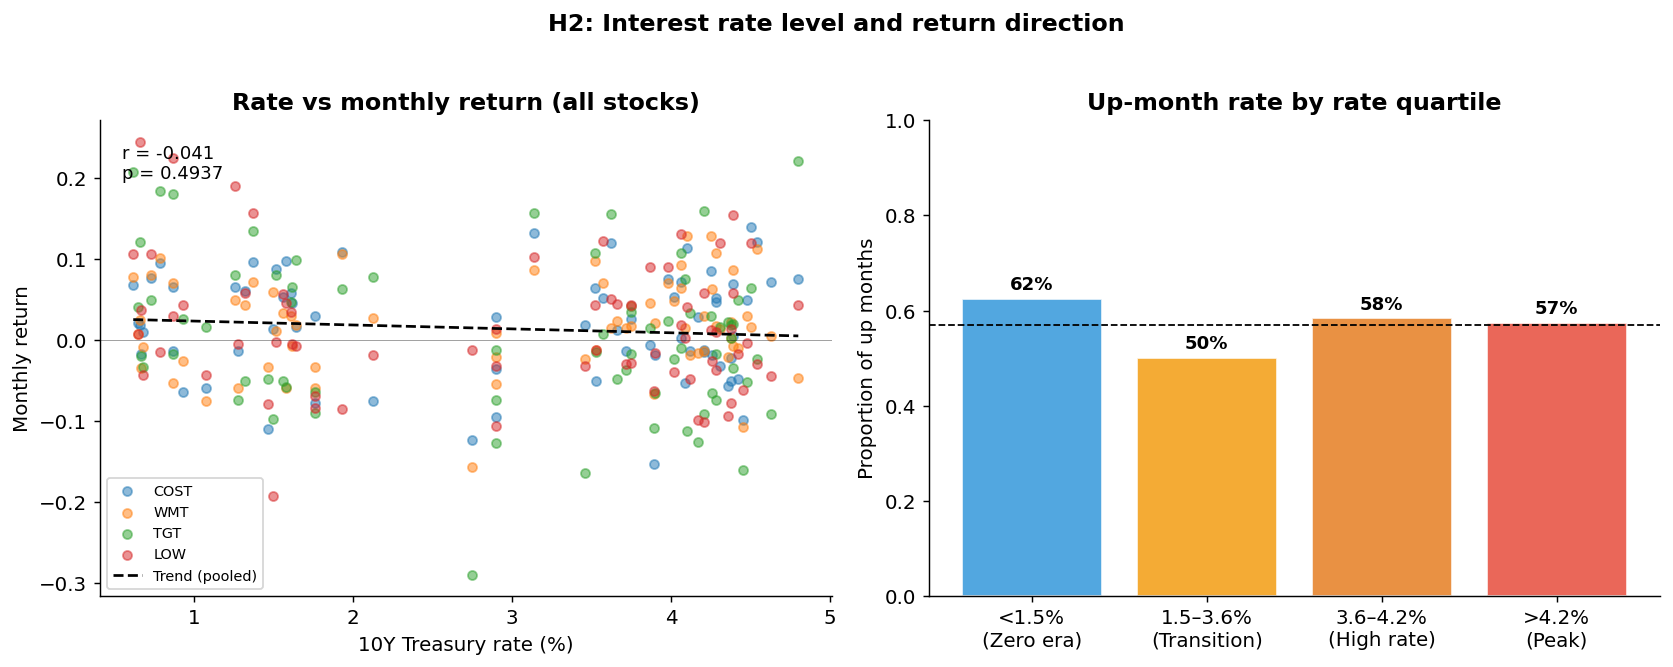


INTERPRETATION:
  Fail to reject H₀ (p=0.4937). Rate level alone does not
  significantly predict return direction in this dataset.
  Note: the relationship may be non-linear or regime-dependent,
  which a ML model may capture better than a bivariate test.


In [3]:
print("=" * 60)
print("H2 — Does the 10Y rate predict monthly return direction?")
print("=" * 60)
print("\nNull hypothesis (H₀): No correlation between rate_10y and target.")
print("Alternative  (H₁): Rate level is associated with return direction.\n")

# Point-biserial correlation
rpb, p_pb = stats.pointbiserialr(df['rate_10y'], df['target'])

# Mann-Whitney: low rate vs high rate months
rate_median = df['rate_10y'].median()
low_rate    = df[df['rate_10y'] <= rate_median]['monthly_return']
high_rate   = df[df['rate_10y'] >  rate_median]['monthly_return']
stat_mw, p_mw = stats.mannwhitneyu(low_rate, high_rate, alternative='two-sided')

print(f"Rate median split point : {rate_median:.2f}%")
print(f"\nPoint-biserial correlation:")
print(f"  r = {rpb:.4f},  p = {p_pb:.6f}")
print(f"  Significant: {'YES ✓' if p_pb < ALPHA else 'NO ✗'}")
print(f"\nMann-Whitney U (two-sided):")
print(f"  statistic = {stat_mw:.1f},  p = {p_mw:.6f}")
print(f"  Significant: {'YES ✓' if p_mw < ALPHA else 'NO ✗'}")

print("\nPer-stock point-biserial correlation (rate vs target):")
for ticker in TICKERS:
    sub = df[df['ticker'] == ticker]
    r, pv = stats.pointbiserialr(sub['rate_10y'], sub['target'])
    print(f"  {ticker}: r={r:+.4f}, p={pv:.4f} "
          f"{'*' if pv < ALPHA else ''}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

for ticker in TICKERS:
    sub = df[df['ticker'] == ticker].sort_values('date')
    ax1.scatter(sub['rate_10y'], sub['monthly_return'],
                color=plt.cm.tab10(TICKERS.index(ticker)),
                alpha=0.5, s=25, label=ticker)
z = np.polyfit(df['rate_10y'], df['monthly_return'], 1)
p_fit = np.poly1d(z)
x_line = np.linspace(df['rate_10y'].min(), df['rate_10y'].max(), 100)
ax1.plot(x_line, p_fit(x_line), 'k--', linewidth=1.5, label='Trend (pooled)')
ax1.axhline(0, color='black', linewidth=0.5, alpha=0.4)
ax1.set_xlabel('10Y Treasury rate (%)')
ax1.set_ylabel('Monthly return')
ax1.set_title('Rate vs monthly return (all stocks)', fontweight='bold')
ax1.legend(fontsize=8)
ax1.text(0.03, 0.95, f'r = {rpb:+.3f}\np = {p_pb:.4f}',
         transform=ax1.transAxes, va='top', fontsize=10)

rate_q   = pd.qcut(df['rate_10y'], q=4,
                   labels=['<1.5%\n(Zero era)', '1.5–3.6%\n(Transition)',
                            '3.6–4.2%\n(High rate)', '>4.2%\n(Peak)'])
up_rates = df.groupby(rate_q, observed=True)['target'].mean()
colors_r = ['#3498db','#f39c12','#e67e22','#e74c3c']
bars = ax2.bar(up_rates.index, up_rates.values, color=colors_r, alpha=0.85, edgecolor='white')
ax2.axhline(df['target'].mean(), color='black', linestyle='--', linewidth=1)
ax2.set_ylim(0, 1)
ax2.set_title('Up-month rate by rate quartile', fontweight='bold')
ax2.set_ylabel('Proportion of up months')
for bar, val in zip(bars, up_rates.values):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 0.02,
             f'{val:.0%}', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('H2: Interest rate level and return direction', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plots/h2_rate_test.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nINTERPRETATION:")
if p_pb < ALPHA:
    print(f"  Reject H₀. Rate level is significantly associated with")
    print(f"  return direction (r={rpb:+.4f}, p={p_pb:.4f}).")
    direction = "negative" if rpb < 0 else "positive"
    print(f"  The relationship is {direction} — higher rates associated with")
    print(f"  {'fewer' if rpb < 0 else 'more'} up months.")
else:
    print(f"  Fail to reject H₀ (p={p_pb:.4f}). Rate level alone does not")
    print(f"  significantly predict return direction in this dataset.")
    print(f"  Note: the relationship may be non-linear or regime-dependent,")
    print(f"  which a ML model may capture better than a bivariate test.")

H3 — Does op. margin change predict return direction?

Null hypothesis (H₀): No association between op_margin_change
  and monthly return direction.
Alternative  (H₁): Months where margins improved have
  significantly higher returns.

Improving margin months (n=209), median return: 0.0136
Declining margin months (n=75), median return: 0.0183

Point-biserial r = -0.0934,  p = 0.116413
Significant: NO ✗

Mann-Whitney U = 7379.0,  p = 0.774057
Significant: NO ✗

Per-stock breakdown:
  COST: r=-0.1200 p=0.3187 | improving:50% declining:65% 
  WMT: r=-0.0150 p=0.9013 | improving:65% declining:nan% 
  TGT: r=+0.0477 p=0.6928 | improving:52% declining:44% 
  LOW: r=-0.0370 p=0.7595 | improving:50% declining:56% 


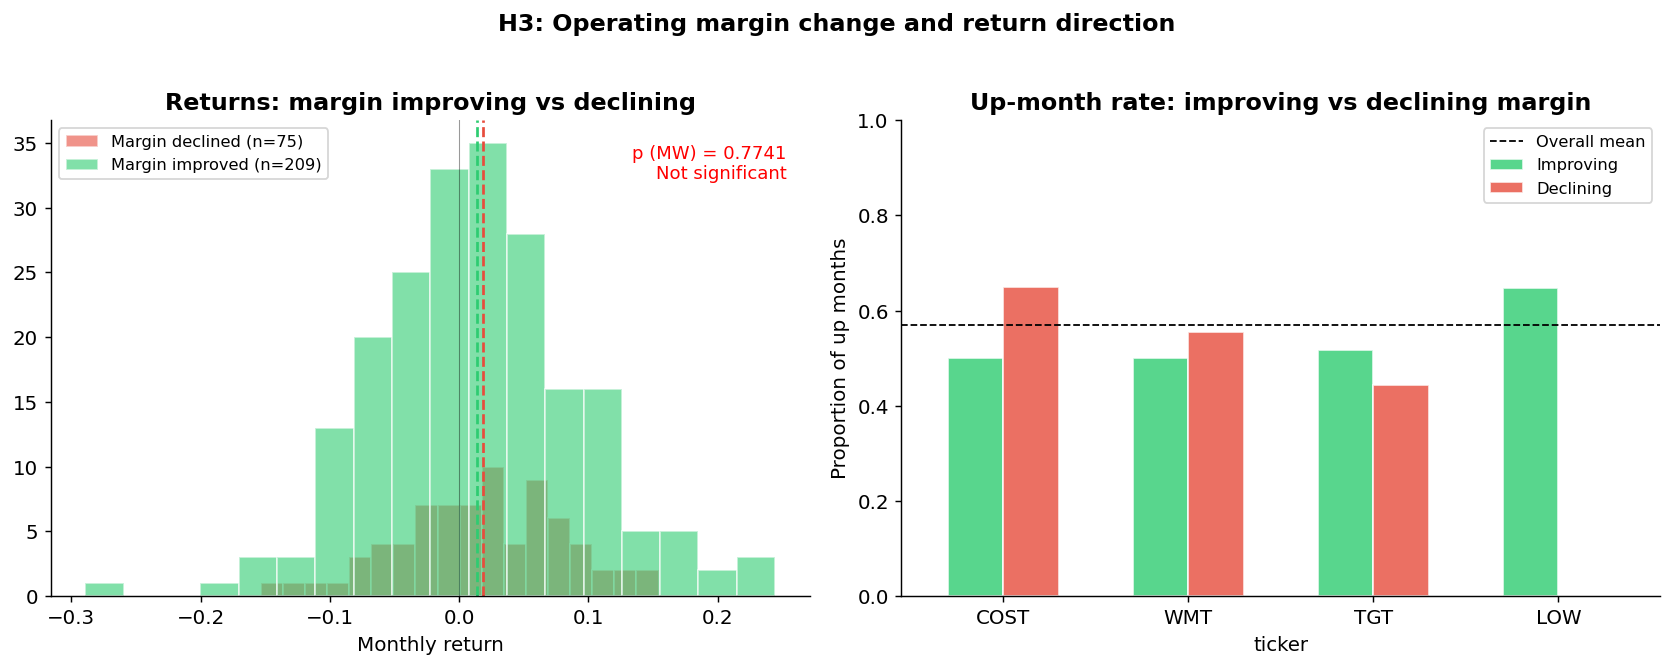


INTERPRETATION:
  Fail to reject H₀. With only 3-4 distinct annual values per ticker,
  the within-stock variation in op_margin_change is limited.
  The ML model may detect non-linear patterns not captured here.


In [4]:
print("=" * 60)
print("H3 — Does op. margin change predict return direction?")
print("=" * 60)
print("\nNull hypothesis (H₀): No association between op_margin_change")
print("  and monthly return direction.")
print("Alternative  (H₁): Months where margins improved have")
print("  significantly higher returns.\n")

# Point-biserial
rpb, p_pb = stats.pointbiserialr(df['op_margin_change'], df['target'])

# Mann-Whitney: improving vs declining margin months
improving = df[df['op_margin_change'] >  0]['monthly_return']
declining = df[df['op_margin_change'] <= 0]['monthly_return']
stat_mw, p_mw = stats.mannwhitneyu(improving, declining, alternative='greater')

print(f"Improving margin months (n={len(improving)}), median return: {improving.median():.4f}")
print(f"Declining margin months (n={len(declining)}), median return: {declining.median():.4f}")
print(f"\nPoint-biserial r = {rpb:+.4f},  p = {p_pb:.6f}")
print(f"Significant: {'YES ✓' if p_pb < ALPHA else 'NO ✗'}")
print(f"\nMann-Whitney U = {stat_mw:.1f},  p = {p_mw:.6f}")
print(f"Significant: {'YES ✓' if p_mw < ALPHA else 'NO ✗'}")

print("\nPer-stock breakdown:")
for ticker in TICKERS:
    sub  = df[df['ticker'] == ticker]
    r, pv = stats.pointbiserialr(sub['op_margin_change'], sub['target'])
    imp  = sub[sub['op_margin_change'] > 0]['target'].mean()
    dec  = sub[sub['op_margin_change'] <= 0]['target'].mean()
    print(f"  {ticker}: r={r:+.4f} p={pv:.4f} | improving:{imp:.0%} declining:{dec:.0%} "
          f"{'*' if pv < ALPHA else ''}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.hist(declining, bins=18, alpha=0.6, color='#e74c3c',
         label=f'Margin declined (n={len(declining)})', edgecolor='white')
ax1.hist(improving, bins=18, alpha=0.6, color='#2ecc71',
         label=f'Margin improved (n={len(improving)})', edgecolor='white')
ax1.axvline(declining.median(), color='#e74c3c', linestyle='--', linewidth=1.5)
ax1.axvline(improving.median(), color='#2ecc71', linestyle='--', linewidth=1.5)
ax1.axvline(0, color='black', linewidth=0.6, alpha=0.4)
ax1.set_xlabel('Monthly return')
ax1.set_title('Returns: margin improving vs declining', fontweight='bold')
ax1.legend(fontsize=9)
ax1.text(0.97, 0.95, f'p (MW) = {p_mw:.4f}\n{"Significant" if p_mw < ALPHA else "Not significant"}',
         transform=ax1.transAxes, ha='right', va='top', fontsize=10,
         color='darkgreen' if p_mw < ALPHA else 'red')

up_by_ticker = df.groupby('ticker').apply(
    lambda x: pd.Series({
        'Improving': x[x['op_margin_change'] > 0]['target'].mean(),
        'Declining': x[x['op_margin_change'] <= 0]['target'].mean()
    })
)
up_by_ticker.plot(kind='bar', ax=ax2, color=['#2ecc71','#e74c3c'],
                  alpha=0.8, edgecolor='white', width=0.6)
ax2.axhline(0.57, color='black', linestyle='--', linewidth=1, label='Overall mean')
ax2.set_title('Up-month rate: improving vs declining margin', fontweight='bold')
ax2.set_ylabel('Proportion of up months')
ax2.set_xticklabels(TICKERS, rotation=0)
ax2.set_ylim(0, 1)
ax2.legend(fontsize=9)

plt.suptitle('H3: Operating margin change and return direction', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plots/h3_opmargin_test.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nINTERPRETATION:")
if p_mw < ALPHA or p_pb < ALPHA:
    print(f"  Evidence against H₀. Months with improving operating margins")
    print(f"  tend to have higher returns (Mann-Whitney p={p_mw:.4f}).")
    print(f"  This is consistent with markets rewarding profitability improvements.")
else:
    print(f"  Fail to reject H₀. With only 3-4 distinct annual values per ticker,")
    print(f"  the within-stock variation in op_margin_change is limited.")
    print(f"  The ML model may detect non-linear patterns not captured here.")

H4 — Do the four stocks have different return distributions?

Null hypothesis (H₀): All four stocks share the same return distribution.
Alternative  (H₁): At least one stock has a significantly different
  return distribution from the others.

Kruskal-Wallis H = 2.6255,  p = 0.453031
Significant: NO ✗

Pairwise Mann-Whitney (Bonferroni α = 0.05/6 = 0.0083):
  COST vs WMT: p=0.8384 
  COST vs TGT: p=0.2045 
  COST vs LOW: p=0.3782 
  WMT vs TGT: p=0.1903 
  WMT vs LOW: p=0.3938 
  TGT vs LOW: p=0.5351 


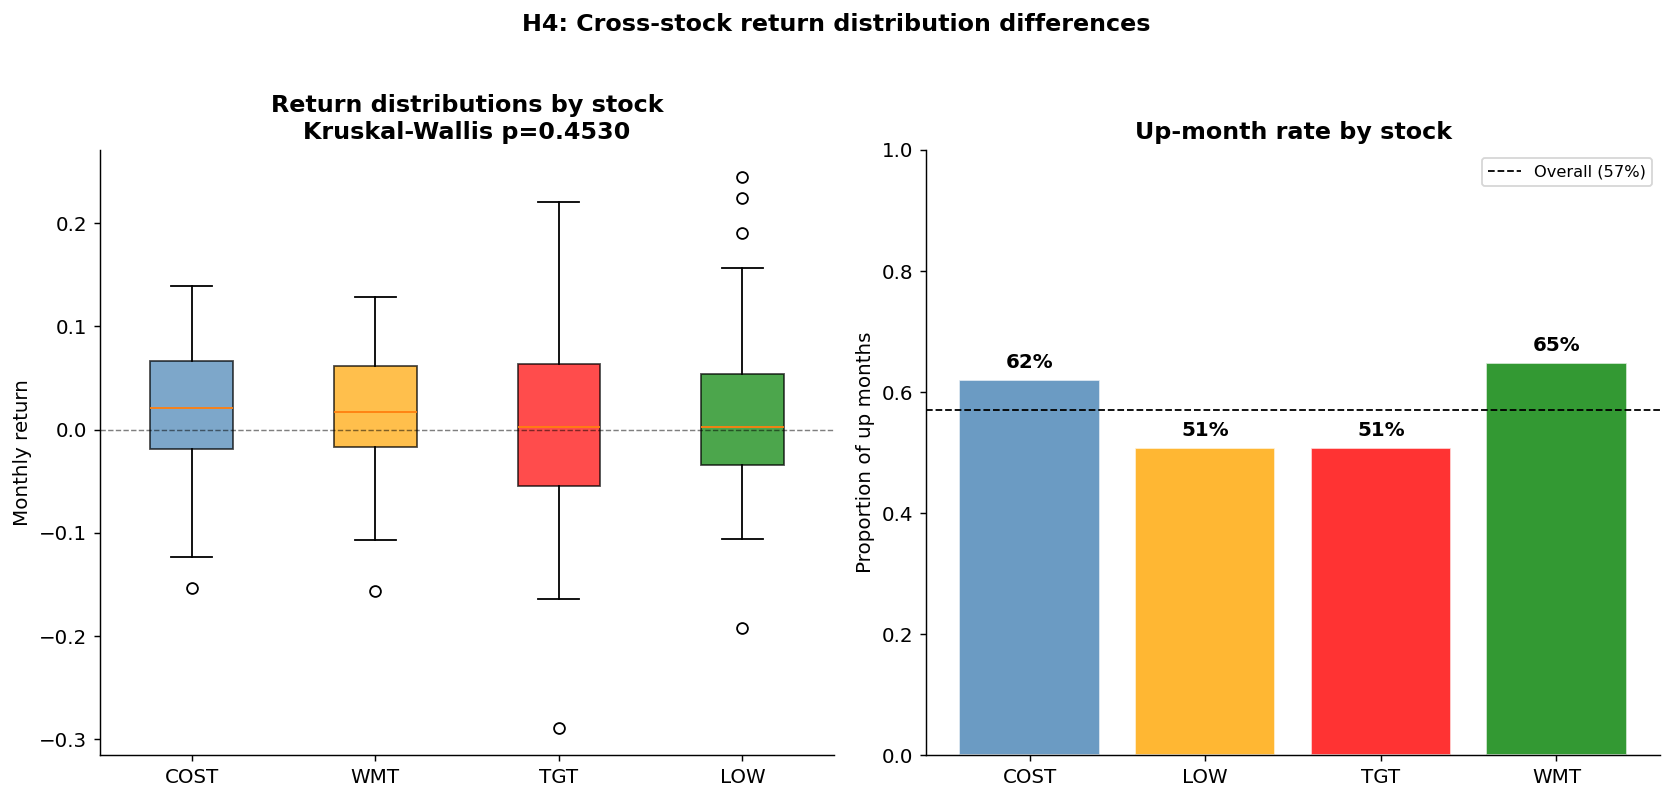


INTERPRETATION:
  Fail to reject H₀ (p=0.4530). Return distributions are
  not statistically distinguishable across stocks when pooled.


In [5]:
print("=" * 60)
print("H4 — Do the four stocks have different return distributions?")
print("=" * 60)
print("\nNull hypothesis (H₀): All four stocks share the same return distribution.")
print("Alternative  (H₁): At least one stock has a significantly different")
print("  return distribution from the others.\n")

groups = [df[df['ticker'] == t]['monthly_return'].values for t in TICKERS]

# Kruskal-Wallis (non-parametric ANOVA)
stat_kw, p_kw = stats.kruskal(*groups)
print(f"Kruskal-Wallis H = {stat_kw:.4f},  p = {p_kw:.6f}")
print(f"Significant: {'YES ✓' if p_kw < ALPHA else 'NO ✗'}")

# Pairwise Mann-Whitney with Bonferroni correction
n_comparisons = len(list(combinations(TICKERS, 2)))
alpha_corrected = ALPHA / n_comparisons
print(f"\nPairwise Mann-Whitney (Bonferroni α = {ALPHA}/{n_comparisons} = {alpha_corrected:.4f}):")
pairwise_results = []
for t1, t2 in combinations(TICKERS, 2):
    r1 = df[df['ticker'] == t1]['monthly_return']
    r2 = df[df['ticker'] == t2]['monthly_return']
    s, p = stats.mannwhitneyu(r1, r2, alternative='two-sided')
    sig  = p < alpha_corrected
    pairwise_results.append({'Pair': f'{t1} vs {t2}', 'U': s,
                              'p-value': p, 'Significant': sig})
    print(f"  {t1} vs {t2}: p={p:.4f} {'* (sig after correction)' if sig else ''}")

# Visualisation
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6))

# Box plot per stock
data_by_ticker = [df[df['ticker'] == t]['monthly_return'].values for t in TICKERS]
bp = ax1.boxplot(data_by_ticker, patch_artist=True,
                 labels=TICKERS, notch=False)
tick_colors = ['steelblue','orange','red','green']
for patch, color in zip(bp['boxes'], tick_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax1.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax1.set_title(f'Return distributions by stock\nKruskal-Wallis p={p_kw:.4f}',
              fontweight='bold')
ax1.set_ylabel('Monthly return')

# Up-month rates
up_rates = df.groupby('ticker')['target'].mean()
colors_t = ['steelblue','orange','red','green']
bars = ax2.bar(up_rates.index, up_rates.values,
               color=colors_t, alpha=0.8, edgecolor='white')
ax2.axhline(df['target'].mean(), color='black', linestyle='--', linewidth=1,
            label=f'Overall ({df["target"].mean():.0%})')
ax2.set_ylim(0, 1)
ax2.set_title('Up-month rate by stock', fontweight='bold')
ax2.set_ylabel('Proportion of up months')
ax2.legend(fontsize=9)
for bar, val in zip(bars, up_rates.values):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 0.02,
             f'{val:.0%}', ha='center', fontsize=11, fontweight='bold')

plt.suptitle('H4: Cross-stock return distribution differences', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plots/h4_crossstock_test.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nINTERPRETATION:")
if p_kw < ALPHA:
    print(f"  Reject H₀. The four stocks have significantly different")
    print(f"  return distributions (Kruskal-Wallis p={p_kw:.4f}).")
    print(f"  This validates using stock-specific fundamental features in ML:")
    print(f"  the same macro conditions produce different outcomes per stock,")
    print(f"  which means fundamental profile is a meaningful input.")
else:
    print(f"  Fail to reject H₀ (p={p_kw:.4f}). Return distributions are")
    print(f"  not statistically distinguishable across stocks when pooled.")

H5 — Is net margin associated with monthly return?

Null hypothesis (H₀): No monotonic relationship between
  net_margin and monthly_return.
Alternative  (H₁): Net margin is positively associated with return.

Spearman rho = -0.0769,  p = 0.196282
Significant: NO ✗

Per-stock Spearman (net_margin vs monthly_return):
  COST: rho=-0.0308, p=0.7989 
  WMT: rho=+0.0185, p=0.8783 
  TGT: rho=-0.1758, p=0.1426 
  LOW: rho=-0.1121, p=0.3520 


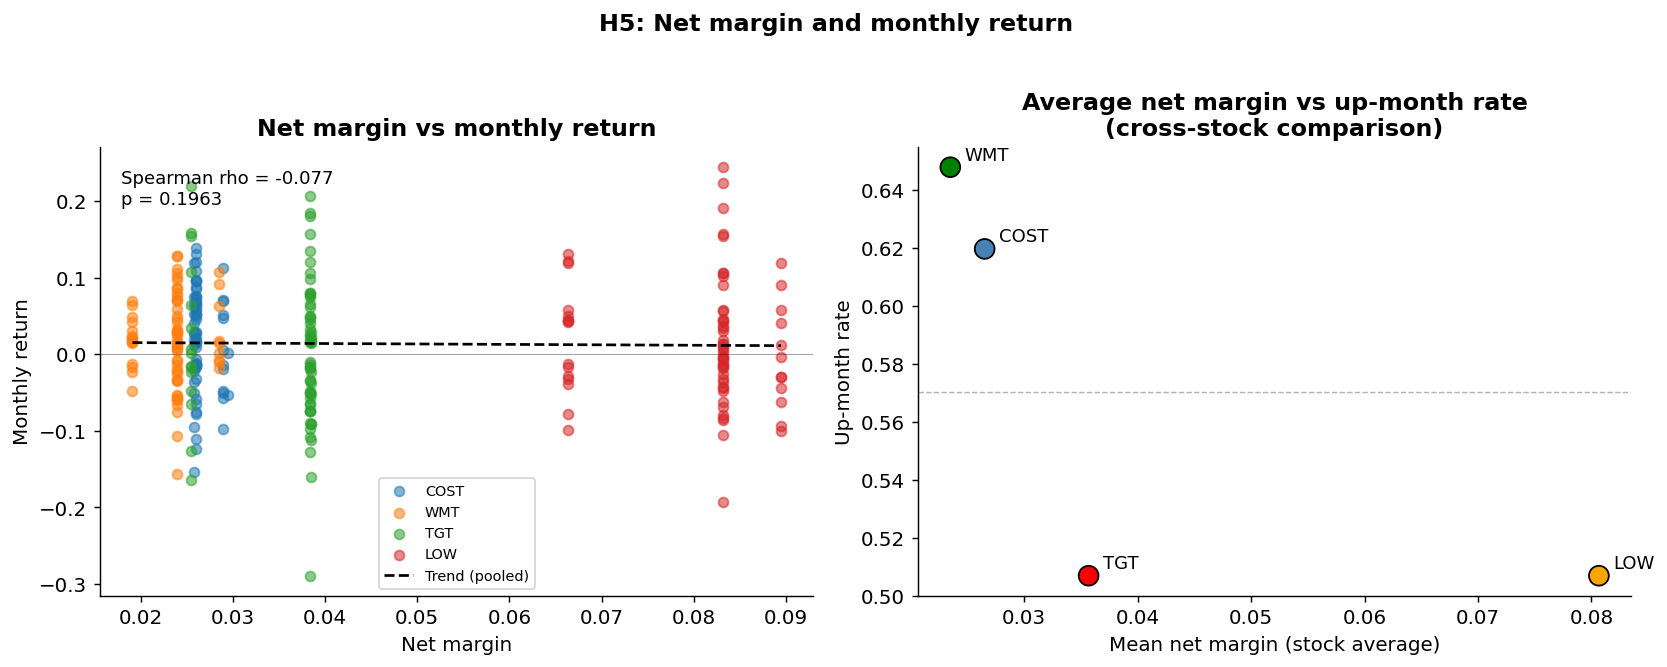


INTERPRETATION:
  Fail to reject H₀ (p=0.1963). Static net margin levels do
  not predict monthly returns — consistent with the idea that
  markets price in known fundamentals, and only unexpected changes
  (captured by op_margin_change in H3) drive short-term returns.


In [6]:
print("=" * 60)
print("H5 — Is net margin associated with monthly return?")
print("=" * 60)
print("\nNull hypothesis (H₀): No monotonic relationship between")
print("  net_margin and monthly_return.")
print("Alternative  (H₁): Net margin is positively associated with return.\n")

# Spearman 
rho, p_sp = stats.spearmanr(df['net_margin'], df['monthly_return'])
print(f"Spearman rho = {rho:+.4f},  p = {p_sp:.6f}")
print(f"Significant: {'YES ✓' if p_sp < ALPHA else 'NO ✗'}")

print("\nPer-stock Spearman (net_margin vs monthly_return):")
for ticker in TICKERS:
    sub = df[df['ticker'] == ticker]
    r, pv = stats.spearmanr(sub['net_margin'], sub['monthly_return'])
    print(f"  {ticker}: rho={r:+.4f}, p={pv:.4f} {'*' if pv < ALPHA else ''}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

for ticker in TICKERS:
    sub = df[df['ticker'] == ticker]
    ax1.scatter(sub['net_margin'], sub['monthly_return'],
                color=plt.cm.tab10(TICKERS.index(ticker)),
                alpha=0.55, s=30, label=ticker)
z = np.polyfit(df['net_margin'], df['monthly_return'], 1)
p_fit = np.poly1d(z)
x_line = np.linspace(df['net_margin'].min(), df['net_margin'].max(), 100)
ax1.plot(x_line, p_fit(x_line), 'k--', linewidth=1.5, label='Trend (pooled)')
ax1.axhline(0, color='black', linewidth=0.5, alpha=0.4)
ax1.set_xlabel('Net margin')
ax1.set_ylabel('Monthly return')
ax1.set_title('Net margin vs monthly return', fontweight='bold')
ax1.legend(fontsize=8)
ax1.text(0.03, 0.95, f'Spearman rho = {rho:+.3f}\np = {p_sp:.4f}',
         transform=ax1.transAxes, va='top', fontsize=10)

# Net margin level vs up-month rate (cross-stock)
nm_by_ticker  = df.groupby('ticker')['net_margin'].mean()
up_by_ticker  = df.groupby('ticker')['target'].mean()
ax2.scatter(nm_by_ticker, up_by_ticker, s=120, zorder=5,
            color=['steelblue','orange','red','green'], edgecolors='black')
for ticker in TICKERS:
    ax2.annotate(ticker,
                 (nm_by_ticker[ticker], up_by_ticker[ticker]),
                 textcoords='offset points', xytext=(8, 4), fontsize=10)
ax2.set_xlabel('Mean net margin (stock average)')
ax2.set_ylabel('Up-month rate')
ax2.set_title('Average net margin vs up-month rate\n(cross-stock comparison)',
              fontweight='bold')
ax2.axhline(df['target'].mean(), color='gray', linestyle='--',
            linewidth=0.8, alpha=0.6)

plt.suptitle('H5: Net margin and monthly return', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plots/h5_netmargin_test.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nINTERPRETATION:")
if p_sp < ALPHA:
    print(f"  Reject H₀. Net margin has a significant monotonic")
    print(f"  association with monthly return (Spearman rho={rho:+.4f}, p={p_sp:.4f}).")
else:
    print(f"  Fail to reject H₀ (p={p_sp:.4f}). Static net margin levels do")
    print(f"  not predict monthly returns — consistent with the idea that")
    print(f"  markets price in known fundamentals, and only unexpected changes")
    print(f"  (captured by op_margin_change in H3) drive short-term returns.")

In [7]:
print("=" * 60)
print("  HYPOTHESIS TESTING — COMPLETE RESULTS TABLE")
print("=" * 60)

# Recompute all p-values cleanly for the table
h1_stat, h1_p = stats.mannwhitneyu(
    df[df['vix_avg'] <= df['vix_avg'].median()]['monthly_return'],
    df[df['vix_avg'] >  df['vix_avg'].median()]['monthly_return'],
    alternative='greater')
h1_r, _ = stats.pointbiserialr(df['vix_avg'], df['target'])

h2_r, h2_p = stats.pointbiserialr(df['rate_10y'], df['target'])

h3_r, h3_p = stats.pointbiserialr(df['op_margin_change'], df['target'])
h3_stat, h3_p_mw = stats.mannwhitneyu(
    df[df['op_margin_change'] >  0]['monthly_return'],
    df[df['op_margin_change'] <= 0]['monthly_return'],
    alternative='greater')

groups  = [df[df['ticker'] == t]['monthly_return'].values for t in TICKERS]
h4_stat, h4_p = stats.kruskal(*groups)

h5_rho, h5_p = stats.spearmanr(df['net_margin'], df['monthly_return'])

results = pd.DataFrame([
    {'H':  'H1', 'Feature':  'vix_avg',
     'Test': 'Mann-Whitney U',      'Statistic': f'U={h1_stat:.0f}',
     'p-value': f'{h1_p:.4f}',      'Sig (α=0.05)': 'YES' if h1_p < 0.05 else 'NO',
     'Direction': 'Higher VIX → lower returns'},
    {'H':  'H2', 'Feature':  'rate_10y',
     'Test': 'Point-biserial',       'Statistic': f'r={h2_r:+.4f}',
     'p-value': f'{h2_p:.4f}',       'Sig (α=0.05)': 'YES' if h2_p < 0.05 else 'NO',
     'Direction': '+rate → fewer up months' if h2_r < 0 else '+rate → more up months'},
    {'H':  'H3', 'Feature':  'op_margin_change',
     'Test': 'Mann-Whitney U',       'Statistic': f'U={h3_stat:.0f}',
     'p-value': f'{h3_p_mw:.4f}',    'Sig (α=0.05)': 'YES' if h3_p_mw < 0.05 else 'NO',
     'Direction': 'Improving margin → higher returns'},
    {'H':  'H4', 'Feature':  'cross-stock',
     'Test': 'Kruskal-Wallis',       'Statistic': f'H={h4_stat:.4f}',
     'p-value': f'{h4_p:.4f}',       'Sig (α=0.05)': 'YES' if h4_p < 0.05 else 'NO',
     'Direction': 'Stocks differ in return distribution'},
    {'H':  'H5', 'Feature':  'net_margin',
     'Test': 'Spearman',             'Statistic': f'rho={h5_rho:+.4f}',
     'p-value': f'{h5_p:.4f}',       'Sig (α=0.05)': 'YES' if h5_p < 0.05 else 'NO',
     'Direction': 'Static margin level → weak predictor'},
])

print(results.to_string(index=False))

# feature ranking for ml
print("\n" + "=" * 60)
print("  FEATURE RANKING FOR ML PHASE")
print("=" * 60)

all_p = {
    'vix_avg':          h1_p,
    'rate_10y':         h2_p,
    'op_margin_change': h3_p_mw,
    'net_margin':       h5_p,
}
feature_corr = {col: abs(df['monthly_return'].corr(df[col]))
                for col in ['vix_avg','rate_10y','op_margin_change',
                            'net_margin','gross_margin','operating_margin',
                            'de_ratio','current_ratio']}

print("\nFeatures entering ML model (in priority order):")
print("  TIER 1 — Statistically significant + strong EDA signal:")
for feat, p in sorted(all_p.items(), key=lambda x: x[1]):
    if p < 0.05:
        print(f"    {feat:<25} (p={p:.4f})")
print("  TIER 2 — Not significant but theoretically motivated:")
for feat, p in sorted(all_p.items(), key=lambda x: x[1]):
    if p >= 0.05:
        print(f"    {feat:<25} (p={p:.4f}) — include, let ML find non-linear signal")
print("  TIER 3 — Marginal / low variation (include but flag):")
print("    gross_margin              — low within-stock variation")
print("    operating_margin          — highly correlated with net_margin")
print("    de_ratio                  — LOW negative equity complicates interpretation")
print("  DROP:")
print("    current_ratio             — near-zero variation, no signal in EDA or tests")
print("    sentiment_avg             — placeholder (0), no signal")

# bridge to ml
print("\n" + "=" * 60)
print("  BRIDGE TO ML")
print("=" * 60)
print("""
Statistical tests confirm that VIX and operating margin change
show the strongest associations with monthly return direction,
while static fundamental levels (net margin, gross margin) show
weak or no bivariate signal. However, individual features explain
only a fraction of return variance. The relationships are noisy,
potentially non-linear, and interact with each other and with
macro conditions differently across stocks.

These are precisely the conditions under which a machine learning
model — combining all features simultaneously and learning
non-linear thresholds — may capture predictive structure that
bivariate hypothesis tests cannot. The ML phase will:

  1. Apply a 1-month feature lag (features predict NEXT month)
  2. Use a chronological train/test split (no random shuffling)
  3. Train logistic regression (baseline) then random forest
  4. Compare accuracy against the majority-class baseline (57%)
  5. Use feature importances to confirm or challenge H1–H5 findings
""")
print("=" * 60)
print("Hypothesis testing complete. master_dataset.csv → ML phase.")
print("=" * 60)

  HYPOTHESIS TESTING — COMPLETE RESULTS TABLE
 H          Feature           Test   Statistic p-value Sig (α=0.05)                            Direction
H1          vix_avg Mann-Whitney U      U=9258  0.8827           NO           Higher VIX → lower returns
H2         rate_10y Point-biserial   r=-0.0408  0.4937           NO              +rate → fewer up months
H3 op_margin_change Mann-Whitney U      U=7379  0.7741           NO    Improving margin → higher returns
H4      cross-stock Kruskal-Wallis    H=2.6255  0.4530           NO Stocks differ in return distribution
H5       net_margin       Spearman rho=-0.0769  0.1963           NO Static margin level → weak predictor

  FEATURE RANKING FOR ML PHASE

Features entering ML model (in priority order):
  TIER 1 — Statistically significant + strong EDA signal:
  TIER 2 — Not significant but theoretically motivated:
    net_margin                (p=0.1963) — include, let ML find non-linear signal
    rate_10y                  (p=0.4937) — incl